Final Weights using SGD:
w1 = 0.8718
w2 = -0.0206
bias = 0.102

Final Weights using Batch:
w1 = 0.8589
w2 = -0.0195
bias = 0.0952

Testing using SGD:
Input: [0 0 1] Target: 0 Output: 0.102
Input: [0 1 1] Target: 0 Output: 0.0815
Input: [1 0 1] Target: 1 Output: 0.9738
Input: [1 1 1] Target: 1 Output: 0.9533

Testing using Batch:
Input: [0 0 1] Target: 0 Output: 0.0952
Input: [0 1 1] Target: 0 Output: 0.0757
Input: [1 0 1] Target: 1 Output: 0.9542
Input: [1 1 1] Target: 1 Output: 0.9347


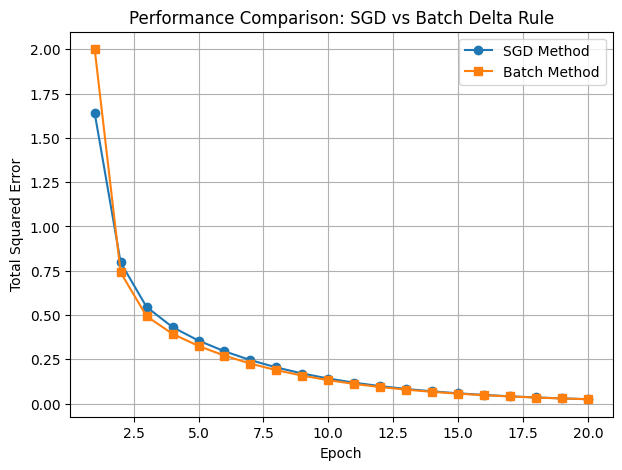

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Input data
# 3rd column = bias input
X = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])

# Target output
D = np.array([0, 0, 1, 1])

# Learning rate and epochs
lr = 0.1
epochs = 20


# --------------------------------
# 1. SGD Method + Delta Rule
# --------------------------------
w_sgd = np.array([0.0, 0.0, 0.0])
sgd_error_list = []

for epoch in range(epochs):
    total_error = 0

    for i in range(len(X)):
        x = X[i]
        target = D[i]

        # Output
        y = np.dot(w_sgd, x)

        # Error
        error = target - y

        # Immediate weight update
        w_sgd = w_sgd + lr * error * x

        # Squared error
        total_error += error ** 2

    sgd_error_list.append(total_error)


# --------------------------------
# 2. Batch Method + Delta Rule
# --------------------------------
w_batch = np.array([0.0, 0.0, 0.0])
batch_error_list = []

for epoch in range(epochs):
    total_error = 0
    total_weight_change = np.array([0.0, 0.0, 0.0])

    for i in range(len(X)):
        x = X[i]
        target = D[i]

        # Output
        y = np.dot(w_batch, x)

        # Error
        error = target - y

        # Collect weight changes
        total_weight_change = total_weight_change + lr * error * x

        # Squared error
        total_error += error ** 2

    # Weight updated once per epoch
    w_batch = w_batch + total_weight_change

    batch_error_list.append(total_error)


# --------------------------------
# 3. Final Weights
# --------------------------------
print("Final Weights using SGD:")
print("w1 =", round(w_sgd[0], 4))
print("w2 =", round(w_sgd[1], 4))
print("bias =", round(w_sgd[2], 4))

print("\nFinal Weights using Batch:")
print("w1 =", round(w_batch[0], 4))
print("w2 =", round(w_batch[1], 4))
print("bias =", round(w_batch[2], 4))


# --------------------------------
# 4. Testing Results
# --------------------------------
print("\nTesting using SGD:")
for i in range(len(X)):
    y = np.dot(w_sgd, X[i])
    print("Input:", X[i], "Target:", D[i], "Output:", round(y, 4))

print("\nTesting using Batch:")
for i in range(len(X)):
    y = np.dot(w_batch, X[i])
    print("Input:", X[i], "Target:", D[i], "Output:", round(y, 4))


# --------------------------------
# 5. Compare Convergence Curves
# --------------------------------
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), sgd_error_list, marker='o', label="SGD Method")
plt.plot(range(1, epochs + 1), batch_error_list, marker='s', label="Batch Method")

plt.xlabel("Epoch")
plt.ylabel("Total Squared Error")
plt.title("Performance Comparison: SGD vs Batch Delta Rule")
plt.legend()
plt.grid(True)
plt.show()